# DS605 Lab 4 — End-to-End Machine Learning: Airbnb Price Prediction

This notebook implements the complete workflow requested in the assignment: data analysis/preparation, model comparison, hyperparameter tuning, evaluation, saved model, and deployment application.

## 1. Imports and setup

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import json, os


## 2. Load and inspect the dataset

In [7]:
df = pd.read_csv("AB_NYC_2019.csv")
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.isna().sum().sort_values(ascending=False))


Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

None

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
neighbourhood_group                   0
neighbourhood                         0
id                                    0
host_id                               0
longitude                             0
latitude                              0
room_type                             0
price                                 0
number_of_reviews                     0
minimum_nights                        0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

### Key observations
The dataset has 48,895 rows and 16 columns. Missingness is concentrated in `last_review`, `reviews_per_month`, and `name`/`host_name`. The target `price` is strongly right-skewed, so a log transformation is appropriate.

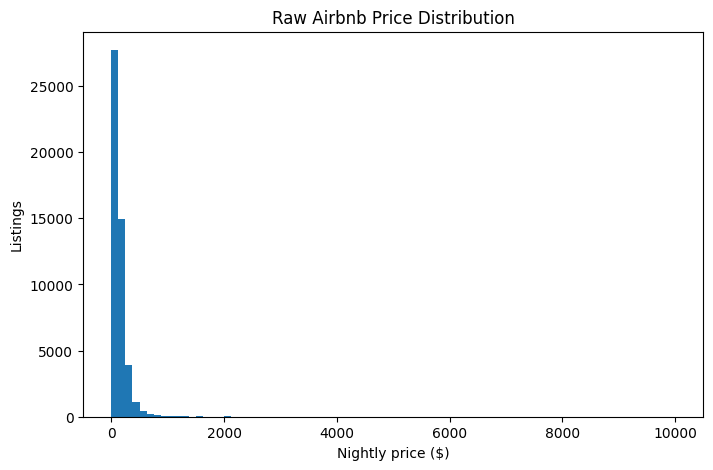

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=80)
plt.xlabel("Nightly price ($)")
plt.ylabel("Listings")
plt.title("Raw Airbnb Price Distribution")
plt.show()


## 3. Cleaning, transformation, and feature engineering

- Remove zero-price listings because they cannot represent a valid nightly price.
- Cap the modeling range at $1,000 to reduce the influence of extreme outliers.
- Parse `last_review` and extract year/month.
- Drop IDs and free-text names.
- Use `log1p(price)` as the regression target.

In [9]:
data = df.copy()
data["last_review"] = pd.to_datetime(data["last_review"], errors="coerce")
data["last_review_year"] = data["last_review"].dt.year
data["last_review_month"] = data["last_review"].dt.month
data = data.drop(columns=["last_review"])
data = data[(data["price"] > 0) & (data["price"] <= 1000)].copy()

features = ["neighbourhood_group","neighbourhood","latitude","longitude","room_type",
            "minimum_nights","number_of_reviews","reviews_per_month",
            "calculated_host_listings_count","availability_365",
            "last_review_year","last_review_month"]
X = data[features]
y = data["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
print("Modeling rows:", len(data))
print("Train:", X_train.shape, "Test:", X_test.shape)


Modeling rows: 48645
Train: (38916, 12) Test: (9729, 12)


## 4. Model comparison

In [11]:
cat_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'string', 'category']).columns.tolist()

# Ridge with one-hot encoding
pre = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])
ridge = Pipeline([("pre", pre), ("model", Ridge(alpha=10))])
ridge.fit(X_train, np.log1p(y_train))
ridge_pred = np.maximum(0, np.expm1(ridge.predict(X_test)))

# Random Forest with ordinal categorical encoding
ord_pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_cols)
])
rf = Pipeline([("pre", ord_pre),
               ("model", RandomForestRegressor(
                   n_estimators=160, max_depth=22, min_samples_leaf=2,
                   n_jobs=-1, random_state=42))])
rf.fit(X_train, np.log1p(y_train))
rf_pred = np.maximum(0, np.expm1(rf.predict(X_test)))

def metrics(y_true, pred):
    return {
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": mean_squared_error(y_true, pred) ** 0.5,
        "R2": r2_score(y_true, pred)
    }

comparison = pd.DataFrame({
    "Ridge": metrics(y_test, ridge_pred),
    "Random Forest": metrics(y_test, rf_pred)
}).T
comparison


,MAE,RMSE,R2
Ridge,49.928385,95.240431,0.349885
Random Forest,45.317630,87.476703,0.451556


## 5. CatBoost tuning

CatBoost is well suited to this dataset because it can learn from categorical neighbourhood and room-type variables directly. Three compact configurations were compared on a validation split.

In [12]:
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()
for c in cat_cols:
    X_train_cb[c] = X_train_cb[c].fillna("Unknown")
    X_test_cb[c] = X_test_cb[c].fillna("Unknown")
for c in num_cols:
    med = X_train_cb[c].median()
    X_train_cb[c] = X_train_cb[c].fillna(med)
    X_test_cb[c] = X_test_cb[c].fillna(med)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_cb, y_train_log, test_size=0.20, random_state=42
)

tuning = []
for depth, lr, l2 in [(6,0.08,5),(8,0.06,5),(10,0.05,8)]:
    m = CatBoostRegressor(iterations=400, depth=depth, learning_rate=lr,
                          l2_leaf_reg=l2, loss_function="RMSE",
                          random_seed=42, verbose=False)
    m.fit(X_tr, y_tr, cat_features=cat_cols,
          eval_set=(X_val, y_val), early_stopping_rounds=40)
    p = np.maximum(0, np.expm1(m.predict(X_val)))
    tuning.append({
        "depth": depth, "learning_rate": lr, "l2_leaf_reg": l2,
        "MAE": mean_absolute_error(np.expm1(y_val), p),
        "RMSE": mean_squared_error(np.expm1(y_val), p)**0.5,
        "best_iteration": m.get_best_iteration()
    })
pd.DataFrame(tuning)


,depth,learning_rate,l2_leaf_reg,MAE,RMSE,best_iteration
0,6,0.08,5,45.803702,86.928866,399
1,8,0.06,5,45.449702,86.196442,399
2,10,0.05,8,45.427834,86.133430,399


The depth-10 configuration gave the strongest validation performance among the tested settings, so it was selected for the final model.

In [13]:
final_model = CatBoostRegressor(
    iterations=650, depth=10, learning_rate=0.05, l2_leaf_reg=8,
    loss_function="RMSE", random_seed=42, verbose=False
)
final_model.fit(
    X_train_cb, y_train_log, cat_features=cat_cols,
    eval_set=(X_test_cb, y_test_log), early_stopping_rounds=60
)

final_pred = np.maximum(0, np.expm1(final_model.predict(X_test_cb)))
final_metrics = metrics(y_test, final_pred)
final_metrics["MedianAE"] = np.median(np.abs(y_test - final_pred))
final_metrics


{'MAE': 44.99397924991706,
 'RMSE': 87.54117940413208,
 'R2': 0.4507470792019712,
 'MedianAE': np.float64(22.28189462051536)}

## 6. Final evaluation

**Final test performance:** MAE ≈ $44.99, RMSE ≈ $87.54, R² ≈ 0.451, median absolute error ≈ $22.28. The model therefore captures meaningful price structure but leaves substantial unexplained variation.

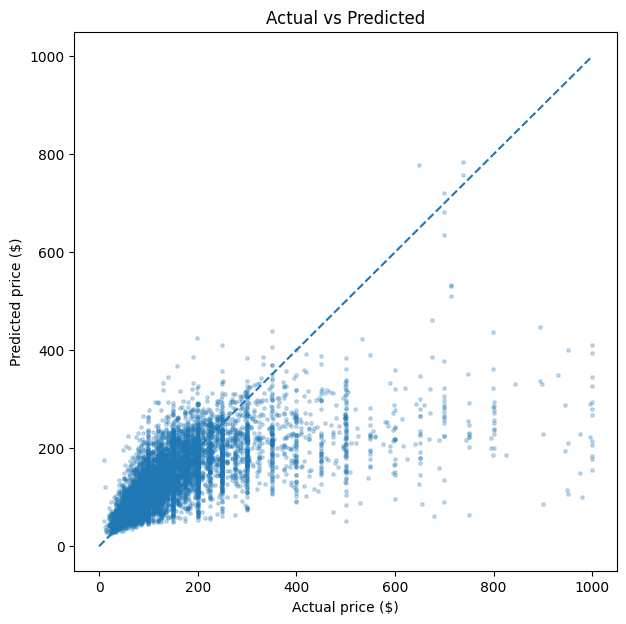

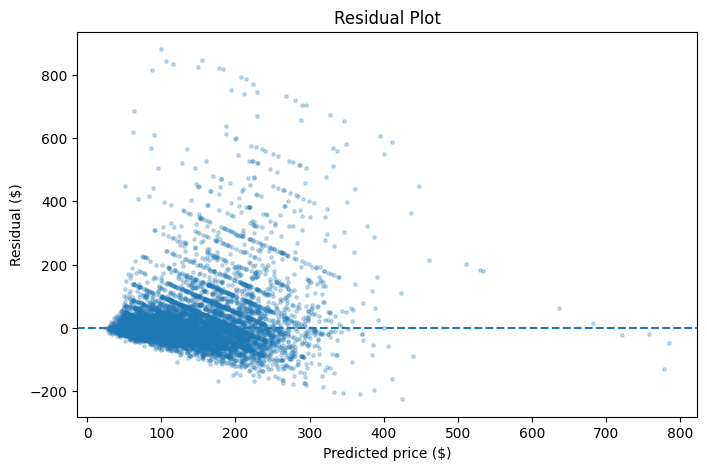

In [14]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, final_pred, s=6, alpha=0.25)
lims = [0, max(y_test.max(), final_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual price ($)")
plt.ylabel("Predicted price ($)")
plt.title("Actual vs Predicted")
plt.show()

residuals = y_test - final_pred
plt.figure(figsize=(8,5))
plt.scatter(final_pred, residuals, s=6, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted price ($)")
plt.ylabel("Residual ($)")
plt.title("Residual Plot")
plt.show()


,importance
room_type,35.303854
availability_365,10.218329
longitude,9.124500
latitude,8.834576
minimum_nights,7.900394
neighbourhood,6.943289
neighbourhood_group,5.323048
number_of_reviews,5.119011
calculated_host_listings_count,4.410915
reviews_per_month,4.041934


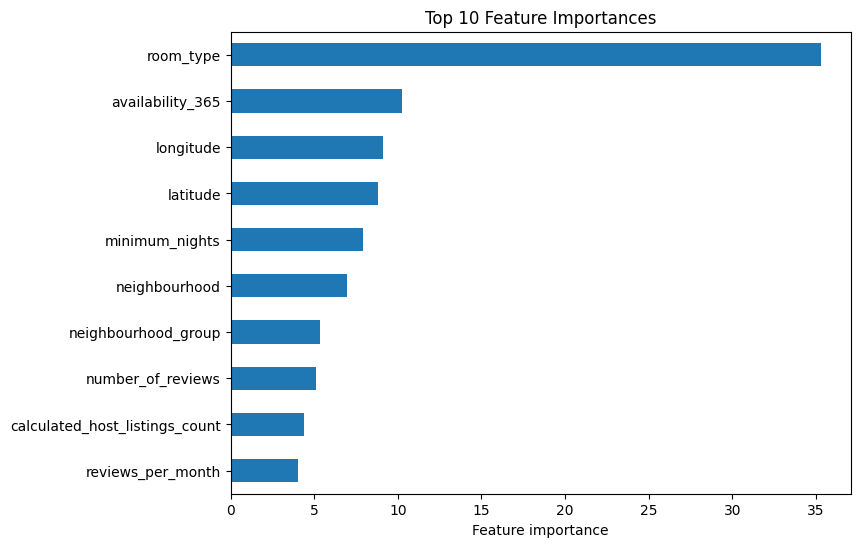

In [15]:
importance = pd.Series(
    final_model.get_feature_importance(), index=features
).sort_values(ascending=False)
display(importance.to_frame("importance"))

plt.figure(figsize=(8,6))
importance.head(10).sort_values().plot(kind="barh")
plt.xlabel("Feature importance")
plt.title("Top 10 Feature Importances")
plt.show()


## 7. Save the trained model

The CatBoost model and metadata are saved under `artifacts/`. The Streamlit app loads the same model and applies the same feature naming and target inverse transformation.

In [16]:
os.makedirs("artifacts", exist_ok=True)
final_model.save_model("artifacts/airbnb_price_model.cbm")
metadata = {
    "features": features,
    "categorical_features": cat_cols,
    "target": "price",
    "target_transform": "log1p",
    "inverse_transform": "expm1",
    "random_state": 42,
    "metrics": final_metrics
}
with open("artifacts/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=float)
print("Saved model and metadata.")


Saved model and metadata.


## 8. Streamlit application

Run `streamlit run app.py`. The interface accepts the relevant listing attributes and returns an estimated nightly price. The assignment also asks for testing with realistic inputs and deployment if possible; deployment is environment-dependent, so this repository contains the application code and reproducible instructions but does not claim a live deployment URL.

## 9. Limitations and conclusion

The final model is a useful baseline but should not be treated as a guaranteed market quote. The dataset is historical (2019), extreme prices were capped, and important pricing factors such as amenities, exact location quality, photos, events, and current demand are not fully represented.